In [ ]:
import mediapipe as mp
import cv2
import numpy as np
import os

#I ran this in another venv than the dynamic model because of some version mismatches, please check the correct requirements file

In [ ]:
subdir = 'PUOH'     #run this cell twice, once for PUOH and once for Other (positive or negative)
# subdir = 'Other'
image_dir = 'E:\Data\Images' '/' + subdir   #assumes there is a subfolder with all PUOH/Other images in the Images folder

mapping = {
    'Other': 0,
    'PUOH': 1,
}

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, min_detection_confidence=0.2)

X = []
y = []
names = []


valid_extensions = ('.jpg', '.jpeg', '.png')
image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith(valid_extensions)
]

print(len(image_files))

for image_file in image_files:
    if 'HT' in image_file or 'TL' in image_file:        #this exludes part of the data set, can be based on the condition
        continue
    image_path = os.path.join(image_dir, image_file)
    image = cv2.imread(image_path)
    if image is None:
        print(f'Could not read {image_file}')
        continue

    # Convert BGR -> RGB
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Detect hands
    results = hands.process(rgb_image)

    # Store one sample
    one_sample = []


    if results.multi_hand_landmarks:

        # Use first detected hand only
        hand_lms = results.multi_hand_landmarks[0]

        for lm in hand_lms.landmark:
            one_sample.extend([lm.x, lm.y])

        # Save sample and label
        X.append(one_sample)
        y.append(mapping[subdir])
        names.append(image_file)
        print(f'Processed: {image_file}')

    else:
        print(f'No hand detected in: {image_file}')

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)
name = np.array(names)

print('\nDataset Shapes:')
print('X shape:', X.shape)
print('y shape:', y.shape)


# Save dataset
save_path = os.path.join('data', f'data_{subdir}.npz')

np.savez(save_path, X=X, y=y, file_name=name)

print(f'\nDataset saved to:')
print(save_path)

567
Processed: 1-11-1-OHD-R.png
Processed: 1-14-1-OHD-L.png
Processed: 1-22-1-OHD-R.png
Processed: 1-23-1-OHD-R.png
Processed: 1-26-1-OHD-R.png
Processed: 1-27-1-OHD-R.png
Processed: 1-28-1-PUOH-R.png
Processed: 1-29-1-OHD-R.png
Processed: 1-30-1-OHD-R.png
Processed: 1-35-1-OHD-R.png
Processed: 1-38-1-OHD-R.png
Processed: 1-41-1-OHD-R.png
Processed: 1-43-1-OHD-R.png
Processed: 1-44-1-OHD-R.png
Processed: 1-47-1-PUOH-R.png
Processed: 1-51-1-PUOH-R.png
Processed: 1-53-1-OHD-R.png
Processed: 1-58-1-PUOH-R.png
Processed: 1-61-1-OHD-R.png
Processed: 1-62-1-PUOH-R.png
Processed: 1-64-1-OHD-R.png
Processed: 1-69-1-OHD-R.png
Processed: 1-71-1-OHD-R.png
Processed: 1-73-1-PUOH-R.png
Processed: 1-74-1-PUOH-R.png
Processed: 1-75-1-PUOH-R.png
Processed: 1-76-1-PUOH-R.png
Processed: 1-78-1-OHD-R.png
Processed: 1-79-1-OHD-R.png
Processed: 1-82-1-OHD-R.png
Processed: 1-83-1-OHD-R.png
Processed: 1-84-1-OHD-R.png
Processed: 1-85-1-OHD-R.png
Processed: 1-87-1-OHD-R.png
Processed: 1-88-1-OHD-R.png
Process

In [295]:
# model_hand_xgb.py
# loads the saved data and trains the XGBoost model for single image classification

import pandas as pd
import xgboost as xgb
import numpy as np
import tensorflow as tf
import datetime as dt
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score
import joblib

# loading data
class_names = ['PUOH', 'Other']
loaded_data = np.load(fr'data\data_{class_names[0]}.npz')
X, y, names = loaded_data['X'], loaded_data['y'], loaded_data['file_name']
for data_class in class_names[1:]:
    loaded_data = np.load(fr'data\data_{data_class}.npz')
    X = np.vstack((X, loaded_data['X']))
    y = np.concatenate((y, loaded_data['y']))
    names = np.concatenate((names, loaded_data['file_name']))

print(X.shape)
print(y.shape)
# print(X)
print(y)
# print(names)

X_train, X_test, y_train, y_test, names_train, names_test = train_test_split(X, y, names, shuffle=True, test_size=0.3, random_state=1, stratify=y)

with tf.device('/GPU:0'):
    # XGBoost model
    base_model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
    )

    param_grid = {
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [50, 100]
    }

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
    )

    grid = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=cv,
        n_jobs=-1,
        verbose=2
    )

    grid.fit(X_train, y_train)

    print("Best CV Macro F1:", grid.best_score_)
    print("Best Params:", grid.best_params_)

    # Best model
    model = grid.best_estimator_
    yhat_test = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, yhat_test)
    print(f'Accuracy: {test_accuracy}')

    date_time_format = '%Y_%m_%d__%H_%M_%S'
    current_date_time_dt = dt.datetime.now()
    current_date_time_str = dt.datetime.strftime(current_date_time_dt, date_time_format)

    model_name = f'model_xgb__date_time_{current_date_time_str}__PUOH+OHD_WithoutUS.pkl'
    joblib.dump(model, model_name)

(1522, 42)
(1522,)
[1 1 1 ... 0 0 0]
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best CV Macro F1: 0.8046948356807512
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Accuracy: 0.811816192560175


0.73
0.553030303030303
0.7516053190413591
0.811816192560175


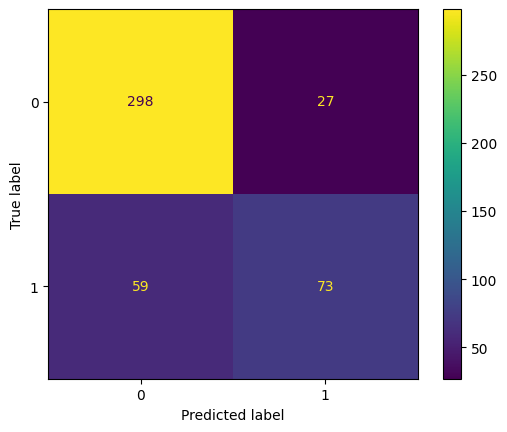

In [296]:
from sklearn import metrics
from matplotlib import pyplot as plt

print(metrics.precision_score(y_test, yhat_test))
print(metrics.recall_score(y_test, yhat_test))
print(metrics.f1_score(y_test, yhat_test, average="macro"))
print(accuracy_score(y_test, yhat_test))

confusion_matrix = metrics.confusion_matrix(y_test, yhat_test)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])

cm_display.plot()
plt.savefig("PUOH+OHD_WithoutUS.png", dpi=300, bbox_inches='tight')


plt.show()
plt.close()

In [297]:
import csv

with open('PUOH+OHD_WithoutUS.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows([names_test, y_test, yhat_test])